# Optimization

examples

In [1]:
import numpy as np
from scipy import linalg as la
import scipy.optimize as opt
from scipy import special
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
np.set_printoptions(suppress=True, precision=6)  # 抑制科学计数法，小数位6位

def sign(x):
    s = np.sign(x)
    return s if s else 1

In [2]:
# 6.6
def f(x):
    return np.array([
        2 * x[0] + x[1] + x[0] * x[1] * x[2],
        2 * x[0] + x[0] ** 2 * x[2],
        x[0] ** 2 * x[1] - 1000 / np.pi, 
    ])

opt.root(f, x0=[1, 2, 3]).x

array([ 5.419261, 10.838521, -0.369054])

In [3]:
B = np.array([
    [-12.6, -6.3],
    [-6.3, 0],
])
Q, R = la.qr(np.array([369, 92.3]).reshape(-1, 1))
Q[:, 1] @ B @ Q[:, 1]

np.float64(2.2241907726339227)

In [4]:
# 6.8
def golden_section_search(f, a, b, n=1000, tol=1e-6):
    r = (np.sqrt(5) - 1) / 2
    x1, x2 = a + (1 - r) * (b - a), a + r * (b - a)
    fx1, fx2 = f(x1), f(x2)
    history = [[x1, fx1, x2, fx2]]
    for _ in range(n):
        if fx1 < fx2:
            b = x2
            x2, fx2 = x1, fx1
            x1 = a + (1 - r) * (b - a)
            fx1 = f(x1)
        else:
            a = x1
            x1, fx1 = x2, fx2
            x2 = a + r * (b - a)
            fx2 = f(x2)
        history.append([x1, fx1, x2, fx2])
        if b - a < tol:
            break
    
    return np.array(history)


def f(x):
    return .5 - x * np.exp(- x ** 2)


golden_section_search(f, 0, 2, n=13)
    

array([[0.763932, 0.073809, 1.236068, 0.231775],
       [0.472136, 0.122204, 0.763932, 0.073809],
       [0.763932, 0.073809, 0.944272, 0.112868],
       [0.652476, 0.07374 , 0.763932, 0.073809],
       [0.583592, 0.084857, 0.652476, 0.07374 ],
       [0.652476, 0.07374 , 0.695048, 0.071243],
       [0.695048, 0.071243, 0.72136 , 0.071291],
       [0.678787, 0.071815, 0.695048, 0.071243],
       [0.695048, 0.071243, 0.705098, 0.071122],
       [0.705098, 0.071122, 0.71131 , 0.071133],
       [0.70126 , 0.071147, 0.705098, 0.071122],
       [0.705098, 0.071122, 0.707471, 0.071118],
       [0.707471, 0.071118, 0.708937, 0.071121],
       [0.706565, 0.071118, 0.707471, 0.071118]])

In [5]:
# 6.9
def successive_parabolic_interpolation(f, u, v, w, n=1000, tol=1e-6):
    history = []
    fu, fv, fw = f(u), f(v), f(w)
    if fu < fv:
        u, fu, v, fv = v, fv, u, fu
    if fw < fv:
        w, fw, v, fv = v, fv, w, fw

    for _ in range(n):
        p = (v - u) ** 2 * (fv - fw) - (v - w) ** 2 * (fv - fu)
        q = 2 * ((v - u) * (fv - fw) - (v - w) * (fv - fu))
        if abs(q) < 1e-8:
            break
        h = - p / q
        u, w, v = w, v, v + h
        fu, fv, fw = fw, f(v), fv
        history.append([v, fv])
        if abs(h) < tol:
            break
    return v, np.array(history)

# successive_parabolic_interpolation(f, 0, .6, 1.2, n=5)
# print(f(1))

_, history = successive_parabolic_interpolation(f, 0, .6, 1.2, n=5)
print(history)

[[0.754267 0.072981]
 [0.720797 0.071278]
 [0.708374 0.071119]
 [0.70692  0.071118]
 [0.707103 0.071118]]


In [6]:
# 6.10
def fprime(x):
    return (2 * x ** 2 - 1) * np.exp(- x ** 2)


def fdoubleprime(x):
    return 2 * x * (3 - 2 * x ** 2) * np.exp(- x ** 2)


def newton(f, fprime, x, tol=1e-6, n=1000):
    history = []
    for _ in range(n):
        fx, fprimex = f(x), fprime(x)
        h = - fx / fprimex
        history.append([x, fx, fprimex, h])
        if abs(h) < tol:
            break
        x += h
    return x, np.array(history)


_, history = newton(fprime, fdoubleprime, 1)
print(history)

[[ 1.        0.367879  0.735759 -0.5     ]
 [ 0.5      -0.3894    1.947002  0.2     ]
 [ 0.7      -0.012253  1.732507  0.007072]
 [ 0.707072 -0.000059  1.715612  0.000035]
 [ 0.707107 -0.        1.715528  0.      ]]


In [7]:
# 6.11
def f(x):
    return .5 * x[0] ** 2 + 2.5 * x[1] ** 2


def fprime(x):
    return np.array([x[0], 5 * x[1]])


def steepest_descent(f, fprime, x, maxstep=1, n=1000, tol=1e-4):
    history = []
    x = np.array(x, dtype=float)
    for _ in range(n):
        s = -fprime(x)
        h, _ = successive_parabolic_interpolation(lambda a: f(x + a * s), u=0, v=maxstep/2, w=maxstep, tol=tol)
        history.append(np.hstack([x, [f(x)], fprime(x), [la.norm(h * s)]]))
        if la.norm(h * s)< tol:
            break
        x += h * s
    
    return x, np.array(history)


_, history = steepest_descent(f, fprime, [5, 1], n=10)
print(history.round(3))


[[ 5.     1.    15.     5.     5.     2.357]
 [ 3.333 -0.667  6.667  3.333 -3.333  1.571]
 [ 2.222  0.444  2.963  2.222  2.222  1.048]
 [ 1.481 -0.296  1.317  1.481 -1.481  0.698]
 [ 0.988  0.198  0.585  0.988  0.988  0.466]
 [ 0.658 -0.132  0.26   0.658 -0.658  0.31 ]
 [ 0.439  0.088  0.116  0.439  0.439  0.207]
 [ 0.293 -0.059  0.051  0.293 -0.293  0.138]
 [ 0.195  0.039  0.023  0.195  0.195  0.092]
 [ 0.13  -0.026  0.01   0.13  -0.13   0.061]]


In [8]:
# 6.12
def n_newton(f, jac, x, args=(), n=100, tol=1e-4):
    history = []
    for _ in range(n):
        h = la.solve(jac(x, *args), -f(x, *args))
        history.append(np.hstack([x, [la.norm(h, ord=np.inf)]]))
        if la.norm(h) < tol:
            break
        x += h
    return x, np.array(history)


def hessian(x):
    return np.array([
        [1, 0],
        [0, 5],
    ])


_, history = n_newton(fprime, hessian, x=[5, 1])
print(history)

[[5. 1. 5.]
 [0. 0. 0.]]


In [9]:
# 6.13
def bfgs(f, x, n=1000, tol=1e-4, B=None):
    x = np.array(x, dtype=float)
    B = np.eye(len(x)) if B is None else B
    fx0 = f(x)
    history = []
    for _ in range(n):
        s = la.solve(B, -fx0)
        x += s
        fx = f(x)
        history.append(np.hstack([x, fx, [la.norm(fx)]]))
        if la.norm(fx) < tol:
            break
        y = fx - fx0
        fx0 = fx
        B += np.outer(y, y) / (y @ s) - (B @ np.outer(s, s) @ B) / (s @ B @ s)
    
    return x, np.array(history)


_, history = bfgs(fprime, [5, 1])
print(history.round(3))

[[  0.     -4.      0.    -20.     20.   ]
 [ -2.222   0.444  -2.222   2.222   3.143]
 [  0.816   0.082   0.816   0.408   0.913]
 [ -0.009  -0.015  -0.009  -0.077   0.077]
 [ -0.001   0.001  -0.001   0.005   0.005]
 [  0.     -0.      0.     -0.      0.   ]]


In [10]:
def conjugate_gradient(f, fprime, x, maxstep=1, tol=1e-4):
    history = []
    x = np.array(x, dtype=float)
    g0 = fprime(x)
    s = - g0
    for _ in range(len(x)):
        h, _ = successive_parabolic_interpolation(lambda a: f(x + a * s), u=0, v=maxstep/2, w=maxstep, tol=tol)
        if la.norm(h * s) < tol:
            break
        x += h * s
        g = fprime(x)
        b = (g @ g) / (g0 @ g0)
        s = - g + b * s
        g0 = g
        history.append(np.hstack([x, s, [la.norm(h * s)]]))
    
    return x, np.array(history)


_, history = conjugate_gradient(f, fprime, [5, 1])
print(history.round(3))

[[ 3.333 -0.667 -5.556  1.111  1.889]
 [-0.     0.     0.     0.     0.   ]]


In [11]:
# 6.15
def row_jac(x, t):
    return np.array([- np.exp(x[1] * t), - np.exp(x[1] * t) * x[0] * t])


def f(x):
    return np.array([
        y - x[0] * np.exp(x[1] * t) for t, y in [(0, 2), (1, .7), (2, .3), (3, .1)]
    ])


def jac(x):
    return np.vstack([row_jac(x, t) for t, _  in [(0, 2), (1, .7), (2, .3), (3, .1)]])


def gauss_newton(f, jac, x, n=1000, tol=1e-6):
    history = []
    x = np.array(x, dtype=float)
    for _ in range(n):
        fx = f(x)
        history.append(np.hstack([x, [la.norm(fx) ** 2]]))
        if la.norm(fx) < tol:
            break
        s = la.lstsq(jac(x), -fx)[0]
        x += s
    return x, np.array(history)


_, history = gauss_newton(f, jac, [1, 0], n=6)
print(history.round(3))

[[ 1.     0.     2.39 ]
 [ 1.69  -0.61   0.213]
 [ 1.975 -0.931  0.007]
 [ 1.994 -1.004  0.002]
 [ 1.995 -1.009  0.002]
 [ 1.995 -1.01   0.002]]


In [12]:
# 6.16
from functools import partial
def f(x, rho):
    return .5 * x[0] ** 2 + 2.5 * x[1] ** 2 + .5 * rho * (x[1] - x[0] + 1) ** 2


def jac(x, rho):
    return np.array([
        x[0] - rho * (x[1] - x[0] + 1),
        5 * x[1] + rho * (x[1] - x[0] + 1),
    ])


x = [1, 1]
for rho in 1, 10, 100, 1000:
    x, history = bfgs(partial(jac, rho=rho), x=x)
    print(rho, x.round(3))


1 [ 0.455 -0.091]
10 [ 0.769 -0.154]
100 [ 0.826 -0.165]
1000 [ 0.833 -0.167]


excercises

In [13]:
# 6.8
def f(x):
    return .5 * (x[0] ** 2 - x[1]) ** 2 + .5 * (1 - x[0]) ** 2


def jac(x):
    return np.array([
        2 * x[0] ** 3 - 2 * x[0] * x[1] + x[0] - 1,
        - x[0] ** 2 + x[1],
    ])


def hessian(x):
    return np.array([
        [6 * x[0] * 2 - 2 * x[1] + 1, - 2 * x[0]],
        [- 2 * x[0], 1],
    ])


x, history = n_newton(jac, hessian, [2, 2], n=2)
print(history)
print(f([2, 2]), f(x))


[[2.       2.       1.2     ]
 [1.8      3.2      0.848889]]
2.5 0.1548107397076773


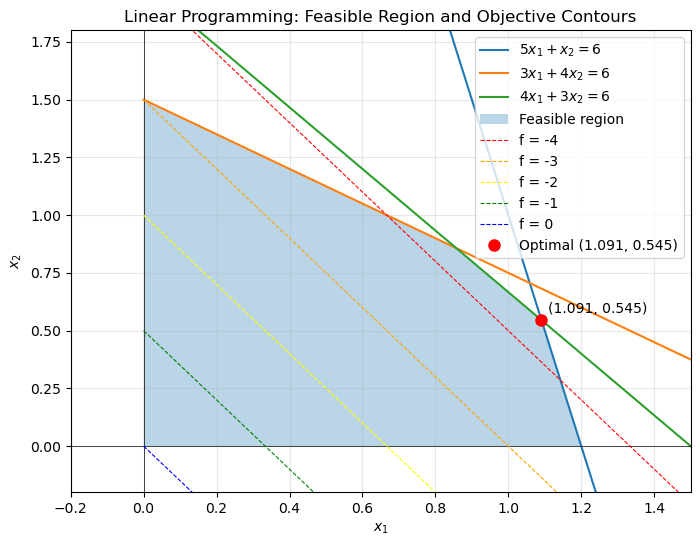

In [14]:
# 6.17 by deepseek
import numpy as np
import matplotlib.pyplot as plt

# 定义约束边界函数（化为 x2 = ... 的形式）
def line1(x1):   # 5x1 + x2 = 6  -> x2 = 6 - 5x1
    return 6 - 5*x1
def line2(x1):   # 3x1 + 4x2 = 6 -> x2 = (6 - 3x1)/4
    return (6 - 3*x1)/4
def line3(x1):   # 4x1 + 3x2 = 6 -> x2 = (6 - 4*x1)/3
    return (6 - 4*x1)/3

# 生成 x1 值范围
x1 = np.linspace(0, 2, 100)

# 创建图形
plt.figure(figsize=(8, 6))

# 1. 绘制约束直线
plt.plot(x1, line1(x1), label='$5x_1 + x_2 = 6$')
plt.plot(x1, line2(x1), label='$3x_1 + 4x_2 = 6$')
plt.plot(x1, line3(x1), label='$4x_1 + 3x_2 = 6$')
# 坐标轴
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

# 2. 确定可行域（多边形顶点）
# 顶点由两两直线及坐标轴交点计算得到（已知顶点）
vertices = np.array([
    [0, 0],           # 原点
    [1.2, 0],         # 与 x1 轴交点 (从 5x1=6)
    [0, 1.5],         # 与 x2 轴交点 (从 4x2=6? 实际是 3x1+4x2=6 当 x1=0 -> x2=1.5)
    [12/11, 6/11],    # 直线1与直线3的交点
    [6/7, 6/7]        # 直线2与直线3的交点？等等，从之前计算最优解在 (12/11,6/11) 和 (6/7,6/7) 都是顶点
    # 实际需要准确交点，这里直接使用已求得的值
])
# 但上述顶点顺序混乱，需要按逆时针或顺时针排列才能正确填充。
# 更好的方法：先获取所有约束的交点，然后筛选可行且按角度排序。
# 为简化，手动给出可行域多边形正确的顶点顺序（逆时针）：
# 从 (0,0) -> (1.2,0) -> (12/11,6/11) -> (6/7,6/7) -> (0,1.5)
# 注意 (0,1.5) 要检查是否满足所有约束：5*0+1.5=1.5≤6，3*0+4*1.5=6≤6，4*0+3*1.5=4.5≤6，成立。
polygon = np.array([
    [0, 0],
    [1.2, 0],
    [12/11, 6/11],
    [6/7, 6/7],
    [0, 1.5]
])
plt.fill(polygon[:,0], polygon[:,1], alpha=0.3, label='Feasible region')

# 3. 绘制目标函数等值线（几条平行线）
# 目标函数 f = -3x1 -2x2，等值线为 -3x1 -2x2 = c  => x2 = -(3/2)x1 - c/2
# 选取几个 c 值，比如 c = -4, -3, -2, -1, 0
c_vals = [-4, -3, -2, -1, 0]
colors = ['red', 'orange', 'yellow', 'green', 'blue']
for c, color in zip(c_vals, colors):
    # 等值线方程：-3x1 -2x2 = c -> x2 = (-c -3x1)/2
    x2_eq = ( -c - 3*x1 ) / 2
    # 只画在图形范围内
    plt.plot(x1, x2_eq, linestyle='--', linewidth=0.8, color=color, label=f'f = {c}')

# 4. 标记最优解
x_opt = 12/11
y_opt = 6/11
plt.plot(x_opt, y_opt, 'ro', markersize=8, label=f'Optimal ({x_opt:.3f}, {y_opt:.3f})')
plt.annotate(f'({x_opt:.3f}, {y_opt:.3f})', (x_opt, y_opt), xytext=(5,5), textcoords='offset points')

# 设置坐标轴范围及标签
plt.xlim(-0.2, 1.5)
plt.ylim(-0.2, 1.8)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Linear Programming: Feasible Region and Objective Contours')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

In [15]:
opt.linprog(c=[-3, -2], A_ub=[
    [5, 1],
    [3, 4],
    [4, 3],
], b_ub=[6, 6, 6])

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -4.363636363636363
              x: [ 1.091e+00  5.455e-01]
            nit: 3
          lower:  residual: [ 1.091e+00  5.455e-01]
                 marginals: [ 0.000e+00  0.000e+00]
          upper:  residual: [       inf        inf]
                 marginals: [ 0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00  5.455e-01  0.000e+00]
                 marginals: [-9.091e-02 -0.000e+00 -6.364e-01]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0

computer problems

10 -2 -4.6494918540685576e-07
10 -4 -0.011239692558726797
10 -6 -0.011239692558726797
10 -8 -0.011239692558726797
10 -10 -0.011239692558726797
10 -12 -0.011239692558726797
10 -14 -0.011239692558726797
10 -16 -0.011239692558726797
10 -18 -0.011239692558726797

10 -2 -4.6494918540685576e-07
10 -4 -4.648879177371939e-07
10 -6 -4.648879177371939e-07
10 -8 -4.648879177371939e-07
10 -10 -4.648879177371939e-07
10 -12 -4.648879177371939e-07
10 -14 -4.648879177371939e-07
10 -16 -4.648879177371939e-07
10 -18 -4.648879177371939e-07

10 -2 -3.88126765152666e-07
10 -4 -3.8808406916543237e-07
10 -6 -3.8808406916543237e-07
10 -8 -3.8808406916543237e-07
10 -10 -3.8808406916543237e-07
10 -12 -3.8808406916543237e-07
10 -14 -3.8808406916543237e-07
10 -16 -3.8808406916543237e-07
10 -18 -3.8808406916543237e-07


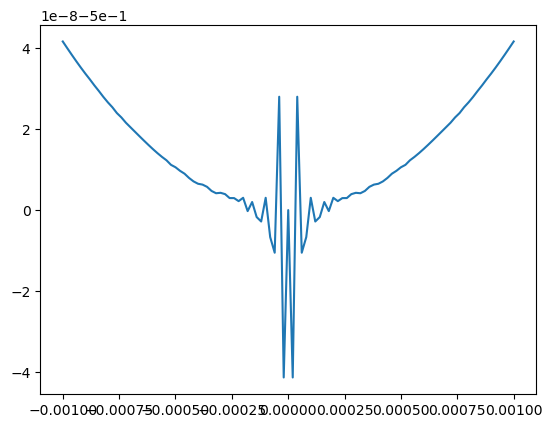

In [16]:
# 6.2
def f(x):
    return - (1 - np.cos(x)) / x ** 2 if x else -.5


for exponent in range(-2, -19, -2):
    tol = 10 ** (exponent)
    x, _ = successive_parabolic_interpolation(f, -2, 1, 2, tol=tol)
    print(10, exponent, x)


x = np.linspace(-.001, .001, 101)
plt.plot(x, [f(a) for a in x])

print()
def f(x):
    return - (1 - np.cos(x)) / x ** 2 if abs(x) > .0001 else -.5

for exponent in range(-2, -19, -2):
    tol = 10 ** (exponent)
    x, _ = successive_parabolic_interpolation(f, -2, 1, 2, tol=tol)
    print(10, exponent, x)


print()
def f(x):
    return - 2 * np.sin(x / 2) ** 2 / x ** 2 if abs(x) > .0001 else -.5

for exponent in range(-2, -19, -2):
    tol = 10 ** (exponent)
    x, _ = successive_parabolic_interpolation(f, -2, 1, 2, tol=tol)
    print(10, exponent, x)

In [17]:
import numpy as np
from scipy.optimize import minimize_scalar

def f(x):
    if abs(x) < 1e-12:
        return 0.25
    return 0.5 * (1 - np.cos(x)) / (x**2)

# We want to maximize f, so minimize -f
def neg_f(x):
    return -f(x)

# Try different tolerances
tolerances = [1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12]
for tol in tolerances:
    res = minimize_scalar(neg_f, bounds=[-2*np.pi, 2*np.pi], method='bounded', options={'xatol': tol})
    print(f"tol={tol:.0e}, x_max={res.x:.10f}, f_max={-res.fun:.10f}")

tol=1e-02, x_max=0.0000000000, f_max=0.2500000000
tol=1e-04, x_max=-0.0000333333, f_max=0.2500000207
tol=1e-06, x_max=0.0000000000, f_max=0.2500000000
tol=1e-08, x_max=0.0000000000, f_max=0.2500000000
tol=1e-10, x_max=0.0000000000, f_max=0.2500000000
tol=1e-12, x_max=-0.0000606005, f_max=0.2500000069


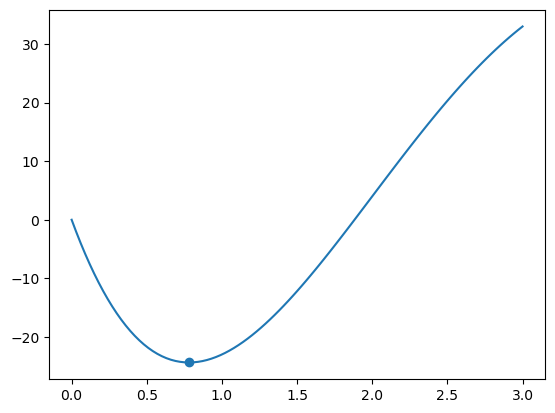

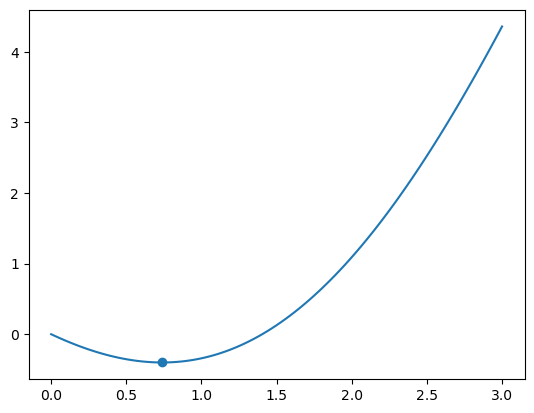

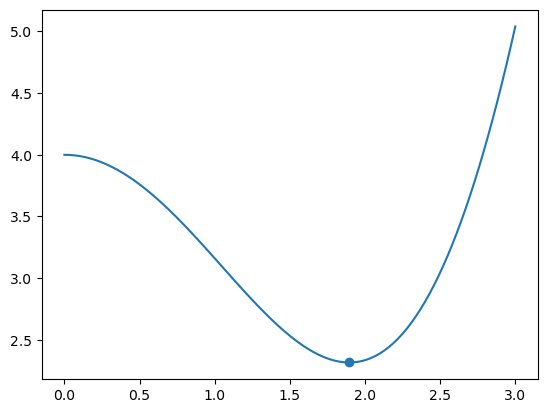

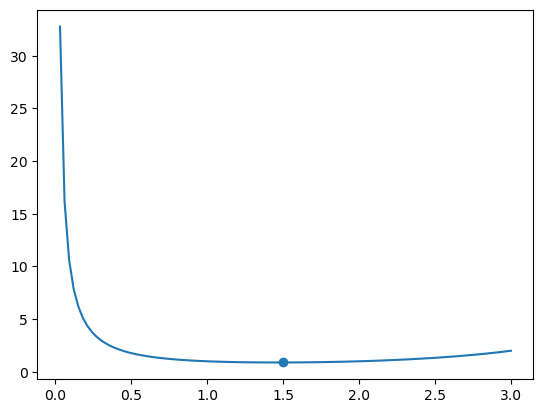

In [18]:
# 6.3
x = np.linspace(0, 3, 101)
def fa(x):
    return x ** 4 - 14 * x ** 3 + 60 * x ** 2 - 70 * x

def fb(x):
    return .5 * x ** 2 - np.sin(x)

def fc(x):
    return x ** 2 + 4 * np.cos(x)

def fd(x):
    return  special.gamma(x)


for f in fa, fb, fc, fd:
    plt.figure()
    plt.plot(x, f(x))
    a, history = successive_parabolic_interpolation(f, 1, 1.5, 2)
    plt.scatter(a, f(a))



(np.float64(8.723117034216354),
 array([[ 7.923875,  0.50851 ],
        [10.591192, -0.744309],
        [ 8.253992,  0.739893],
        [ 8.788645,  1.065865],
        [ 8.96278 ,  0.937224],
        [ 8.681557,  1.072006],
        [ 8.723267,  1.075829],
        [ 8.721635,  1.075824],
        [ 8.723117,  1.075829]]))

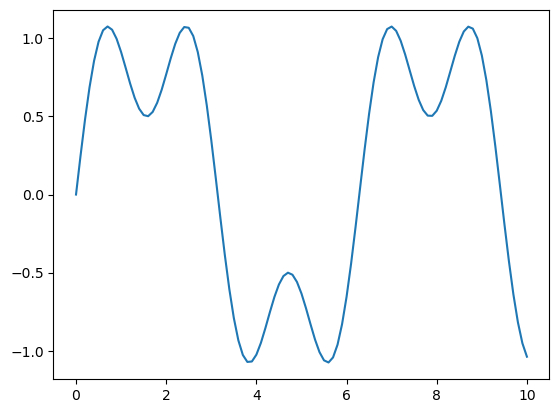

In [19]:
# 6.4
x = np.linspace(0, 10, 101)


def f(x):
    return np.sin(x) + 0.5 * np.sin(3*x)   # Non‑unimodal on [0, 10]


plt.plot(x, f(x))

successive_parabolic_interpolation(f, 6, 7, 9)

[-1.747602  0.873801] 0.29863845648924614
[12.253716+0.j  1.902474+0.j]
[-1.070544  0.535272] 0.877361557755544
[-4.038693+0.j  2.165599+0.j]
[0. 0.] 0.0
[4.414214+0.j 1.585786+0.j]
[ 1.070544 -0.535272] 0.877361557755544
[-4.038693+0.j  2.165599+0.j]
[ 1.747554 -0.873777] 0.2986384422449325
[12.250717+0.j  1.902446+0.j]


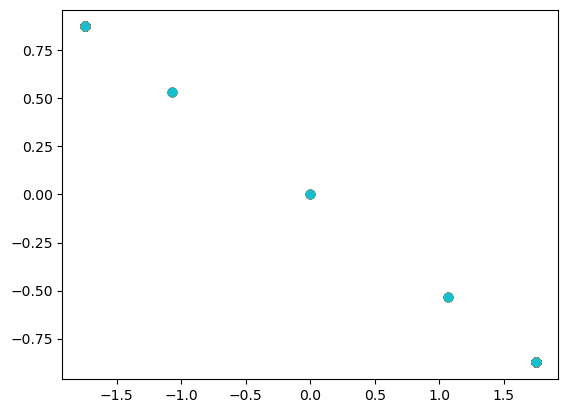

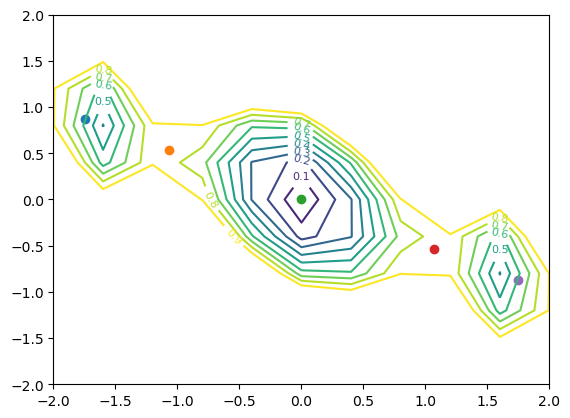

In [20]:
# 6.8
def f(x):
    return 2 * x[0] ** 2 - 1.05 * x[0] ** 4 + x[0] ** 6 / 6 + x[0] * x[1] + x[1] ** 2


def gradient(x):
    return np.array([
        4 * x[0] - 4.2 * x[0] ** 3 + x[0] ** 5 + x[1],
        x[0] + 2 * x[1],
    ])


def hessian(x):
    return np.array([
        [4 - 12.6 * x[0] ** 2 + 5 * x[0] ** 4, 1],
        [1, 2],
    ])


solutions = []
for a in range(-10, 10, 1):
    for b in range(-10, 10, 1):
        x, history = n_newton(gradient, hessian, [a, b])
        if not solutions:
            solutions.append(x)
        else:
            if all(la.norm(x - s, ord=np.inf) > .1 for s in solutions):
                solutions.append(x)
        plt.scatter(*x)
        


plt.figure()
X, Y = np.meshgrid(np.linspace(-2, 2, 11), np.linspace(-2, 2, 11))
Z = np.zeros_like(X)
for i in range(len(X)):
    for j in range(len(X[0])):
        Z[i, j] = f([X[i, j], Y[i, j]])


contour = plt.contour(X, Y, Z, levels=np.arange(10) / 10)
plt.clabel(contour, inline=True, fontsize=8)   # 添加数值标签

for x in solutions:
    print(x, f(x))
    print(la.eig(hessian(x))[0])
    plt.scatter(*x)


[[ -1.         1.         4.        -4.         0.         0.023951]
 [ -0.976049   1.         4.128769  14.525906   9.465716   0.018145]
 [ -0.991251   0.990094   3.970728  -1.002849   1.502976   0.976809]
 [ -0.449091   0.177555   2.15808   -7.232408  -4.825551   0.934057]
 [  0.327895   0.69597   35.079632 -78.524866 117.690964   0.443434]
 [  0.574008   0.327104   0.182036  -0.305226  -0.476264   0.322358]
 [  0.747944   0.598508   0.216316 -12.198241   7.817513   0.022149]
 [  0.766593   0.586557   0.054602  -0.127308  -0.221438   0.415273]
 [  0.973571   0.946573   0.000859   0.441073  -0.253669   0.000928]
 [  0.972767   0.947035   0.000799  -0.350313   0.152064   0.000419]
 [  0.973152   0.946868   0.000723   0.006819  -0.031093   0.000082]] 

[[  0.         1.       101.        -2.       200.         0.999865]
 [  0.009998   0.000185   0.980104  -1.980345   0.017063   0.147752]
 [  0.157745  -0.001088   0.776844  -0.045785  -5.194229   0.026119]
 ...
 [  0.927521   0.860082   

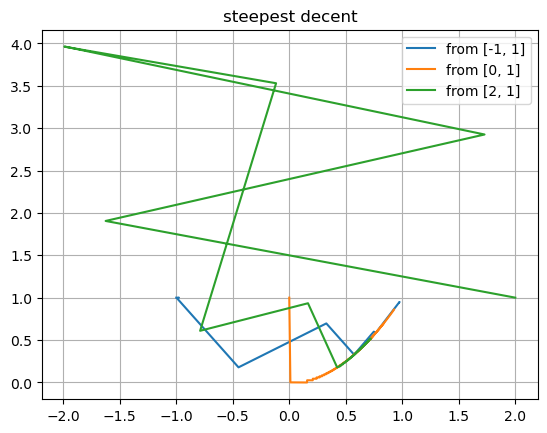

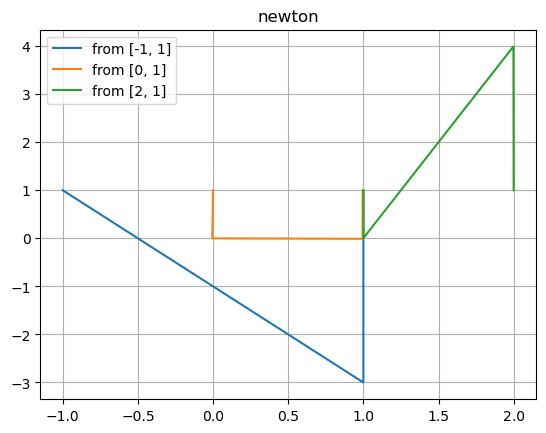

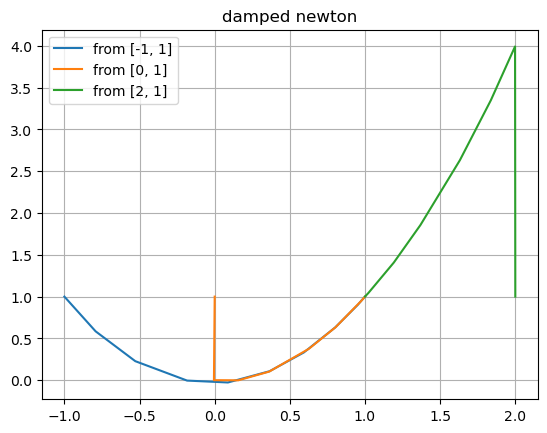

In [21]:
# 6.9
def f(x):
    return 100 * (x[1] - x[0] ** 2) ** 2 + (1 - x[0]) ** 2


def gradient(x):
    return np.array([
        400 * x[0] ** 3 - 400 * x[0] * x[1] + 2 * x[0] - 2,
        200 * x[1] - 200 * x[0] ** 2,
    ])


def hessian(x):
    return np.array([
        [1200 * x[0] ** 2 - 400 * x[1] + 2, - 400 * x[0]],
        [-400 * x[0], 200],
    ])


plt.figure()
for x in [-1, 1], [0, 1], [2, 1]:
    # (a)
    _, history = steepest_descent(f, gradient, x)
    print(history, '\n')
    plt.plot(history[:, 0], history[:, 1], label=f'from {x}')
plt.title('steepest decent')
plt.grid(True)
plt.legend()

plt.figure()
for x in [-1, 1], [0, 1], [2, 1]:
    # (b)
    _, history = n_newton(gradient, hessian, x)
    print(history, '\n')
    plt.plot(history[:, 0], history[:, 1], label=f'from {x}')

    # (c)
    def n_newton_damped(f, jac, hessian, x, n=1000, tol=1e-4):
        history = []
        for _ in range(n):
            h = la.solve(hessian(x), -jac(x))
            if la.norm(h) > .1:
                s = successive_parabolic_interpolation(lambda a: f(x + a * h), 0, .5, 1)[0]
            else:
                s = 1
            history.append(np.hstack([x, [la.norm(s * h, ord=np.inf)]]))
            if la.norm(h) < tol:
                break
            x += s * h
        return x, np.array(history)
plt.title('newton')
plt.grid(True)
plt.legend()

plt.figure()
for x in [-1, 1], [0, 1], [2, 1]:
    _, history = n_newton_damped(f, gradient, hessian, x)
    print(history, '\n')
    plt.plot(history[:, 0], history[:, 1], label=f'from {x}')
plt.title('damped newton')
plt.grid(True)
plt.legend()

In [22]:
# 6.10
A = np.array([
    [6, 2, 1],
    [2, 3, 1],
    [1, 1, 1],
])


def f(x):
    return (x @ A @ x) / (x @ x)


def gradient(x):
    return 2 * ((x @ x) * (A @ x) - (x @ A @ x) * x) / (x @ x) ** 2


# (a)
m = la.norm(A, ord=2) # 7.287992138960423
x, history = conjugate_gradient(f, gradient, np.arange(3))
print(history)
print(f(x))
print()

x, history = conjugate_gradient(lambda x: -f(x), lambda x: -gradient(x), np.arange(3))
print(history)
print(f(x))
print()

la.eig(A)[0]

[[-0.865222  0.394345  2.302828  0.231372 -0.528027  0.264017  0.342884]
 [-0.172368 -1.186856  3.093439  0.040322  0.019413  0.012327  0.139003]
 [-0.139374 -1.170972  3.103526 -0.000999  0.001899  0.000679  0.001841]]
0.5789423432768197

[[ 3.583797  3.508658  0.745671  0.517458 -0.327768  0.163882  1.420249]
 [ 5.002159  2.610239  1.194875 -0.001578  0.000365  0.005975  0.01697 ]
 [ 4.998056  2.611189  1.210414 -0.000298  0.000592 -0.000042  0.001726]]
7.287991469029955



array([7.287992+0.j, 2.133074+0.j, 0.578933+0.j])

In [23]:
print(f(opt.minimize(f, x0=np.arange(3)).x))
print(f(opt.minimize(lambda x: -f(x), x0=np.arange(3)).x))

# (b)
def g(x):
    return x @ x - 1

cons = {'type': 'eq', 'fun': g}
print(f(opt.minimize(f, x0=np.arange(3), constraints=cons).x))
print(f(opt.minimize(lambda x: -f(x), x0=np.arange(3), constraints=cons).x))

0.5789333856910527
7.287992138943926
0.5789333857461313
7.2879921363695255


In [24]:
# 6.13
# (a)
def f(x):
    return np.array([
        2 - x[0] ** 2 - x[1] ** 2,
        2 - (x[0] - 2) ** 2 - x[1] ** 2,
        9 - (x[0] - 1) ** 2 - x[1] ** 2,
    ])


def jac(x):
    return np.array([
        [- 2 * x[0], - 2 * x[1]],
        [- 2 * (x[0] - 2), - 2 * x[1]],
        [- 2 * (x[0] - 1), - 2 * x[1]],
    ])


print(gauss_newton(f, jac, np.arange(2)))

opt.least_squares(f, np.arange(2))

(array([1.      , 1.914854]), array([[ 0.      ,  1.      , 59.      ],
       [ 1.      ,  2.833333, 99.724537],
       [ 1.      ,  2.063725, 43.719111],
       ...,
       [ 1.      ,  1.914854, 42.666667],
       [ 1.      ,  1.914854, 42.666667],
       [ 1.      ,  1.914854, 42.666667]], shape=(1000, 3)))


     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-2.667e+00 -2.667e+00  5.333e+00]
           x: [ 1.000e+00  1.915e+00]
        cost: 21.333333333333336
         jac: [[-2.000e+00 -3.830e+00]
               [ 2.000e+00 -3.830e+00]
               [ 0.000e+00 -3.830e+00]]
        grad: [-3.179e-07 -1.660e-07]
  optimality: 3.178914234069907e-07
 active_mask: [ 0.000e+00  0.000e+00]
        nfev: 6
        njev: 6

In [25]:
# (b)
def f(x):
    return np.array([
        - x[0] ** 2 - x[1] ** 2 - x[0] * x[1],
        - np.sin(x[0]) ** 2,
        - np.cos(x[1]) ** 2,
    ])


def jac(x):
    return np.array([
        [- 2 * x[0] - x[1], - 2 * x[1] - x[0]],
        [- 2 * np.sin(x[0]) * np.cos(x[0]), 0],
        [0, 2 * np.sin(x[1]) * np.cos(x[1])],
    ])

print(gauss_newton(f, jac, np.arange(2)))
opt.least_squares(f, np.arange(2))

(array([ 0.221508, -0.745089]), array([[ 0.      ,  1.      ,  1.085221],
       [-1.642093,  1.321046,  6.157188],
       [-0.644231,  1.089923,  0.98733 ],
       ...,
       [ 0.086184, -0.844408,  0.614135],
       [ 1.716383, -1.16958 ,  6.301283],
       [ 0.76181 , -1.19025 ,  1.434774]], shape=(1000, 3)))


     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-4.365e-01 -9.593e-02 -5.261e-01]
           x: [-3.149e-01  7.592e-01]
        cost: 0.23829199497404954
         jac: [[-1.295e-01 -1.204e+00]
               [ 5.890e-01  0.000e+00]
               [-0.000e+00  9.986e-01]]
        grad: [ 1.415e-05 -7.996e-06]
  optimality: 1.4148550908060775e-05
 active_mask: [ 0.000e+00  0.000e+00]
        nfev: 18
        njev: 13

In [26]:
# 6.14
tys = [
    [.5, 6.8],
    [1, 3],
    [1.5, 1.5],
    [2, .75],
    [2.5, .48],
    [3, .25],
    [3.5, .2],
    [4, .15],
]


def f(x):
    return np.array([y - x[1] * np.exp(x[0] * t) for t, y in tys])


def jac(x):
    return np.array([[- x[1] * t * np.exp(x[0] * t), - np.exp(x[0] * t)] for t, y in tys])


print(gauss_newton(f, jac, np.arange(2)))
opt.least_squares(f, np.arange(2))

(array([-1.513916, 14.376629]), array([[ 0.      ,  1.      , 40.1479  ],
       [-1.537381,  5.100357, 24.772482],
       [-1.474806, 14.39021 ,  0.14474 ],
       ...,
       [-1.513916, 14.376629,  0.09591 ],
       [-1.513916, 14.376629,  0.09591 ],
       [-1.513916, 14.376629,  0.09591 ]], shape=(1000, 3)))


     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 5.605e-02 -1.635e-01  1.602e-02  5.388e-02  1.535e-01
                9.682e-02  1.281e-01  1.163e-01]
           x: [-1.514e+00  1.438e+01]
        cost: 0.047954947918256274
         jac: [[-3.372e+00 -4.691e-01]
               [-3.164e+00 -2.200e-01]
               ...
               [-2.515e-01 -4.998e-03]
               [-1.348e-01 -2.345e-03]]
        grad: [ 1.133e-06  3.626e-11]
  optimality: 1.1328463632997998e-06
 active_mask: [ 0.000e+00  0.000e+00]
        nfev: 9
        njev: 9

In [27]:
# (b)
A = [[1, t] for t, _ in tys]
b = [np.log(y) for _, y in tys]

x = la.lstsq(A, b)[0]
print(np.exp(x[0]), x[1])

8.634952470204112 -1.0966693975071244


In [28]:
# 6.17
tys = [
    [0, 20],
    [.25, 51.58],
    [.5, 68.73],
    [.75, 75.46],
    [1, 74.36],
    [1.25, 67.09],
    [1.5, 54.73],
    [1.75, 37.98],
    [2, 17.28],
]


def f(t, x):
    return x[0] + x[1] * t + x[2] * t ** 2 + x[3] * np.exp(x[4] * t)


def residual(x):
    return np.array([y - f(t, x) for t, y in tys])


def phi(x):
    return .5 * (residual(x) @ residual(x))

x0 = [10.0, 50.0, -20.0, 10.0, -20.0]
# x0 = np.arange(5)
# (a)
print(opt.minimize(phi, x0).x)

# (b)
def r_jac(x):
    return np.array([
        [-1, -t, -t ** 2, -np.exp(x[4] * t), -x[3] * t * np.exp(x[4] * t)] for t, _ in tys
    ])


def gradient(x):
    return r_jac(x).T @ residual(x)


print(opt.root(gradient, x0).x)

[109.728242   5.231906 -25.05451  -89.72808   -1.752891]
[  35.266964   87.028333  -48.484762  -15.266964 -132.451833]


In [29]:
# (c)
def g(x):
    A = np.array([
        [1, t, t**2, np.exp(x * t)] for t, _ in tys
    ])
    b = [y for _, y in tys]
    return la.lstsq(A, b)[1]


x = opt.minimize_scalar(g, bounds=[-20, 20]).x
print('x5', x)

A = np.array([
    [1, t, t**2, np.exp(x * t)] for t, _ in tys
])
b = [y for _, y in tys]
print(la.lstsq(A, b)[0])


# (d)
def gprime(x):
    h = 1e-5
    return (g(x + h) - g(x - h)) / 2 / h


x = opt.root_scalar(gprime, x0=-1).root
print('x5', x)

A = np.array([
    [1, t, t**2, np.exp(x * t)] for t, _ in tys
])
b = [y for _, y in tys]
print(la.lstsq(A, b)[0])

x5 -1.7528804173062154
[109.729163   5.231139 -25.054335 -89.728997]
x5 -1.7528813636375369
[109.729081   5.231207 -25.05435  -89.728916]


In [30]:
# (e)
gauss_newton(residual, r_jac, x0)[0]

array([  35.266964,   87.028333,  -48.484762,  -15.266964, -512.771494])

In [31]:
# 6.18
def f(x):
    return 5 * x[0] * x[1] * x[3] - 4 * x[0] * x[1] ** 1.4 - .75 * x[2] ** .6


def eq(x):
    return x[0] * x[3] - 8.4 * x[1] * x[2] * (1 - x[3]) ** 2



def g(x):
    return -f(x)

bounds = [
    (0, None),
    (0, None), 
    (0, None), 
    (0, 1)
] 

opt.minimize(g, x0=[0, 1, 1, 1], constraints=[
    {'type': 'eq', 'fun': eq}], bounds=bounds
)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -2.0939250587189555e-12
           x: [ 2.094e-12  1.000e+00  0.000e+00  1.000e+00]
         nit: 3
         jac: [-1.000e+00  1.256e-12  1.013e+03 -1.047e-11]
        nfev: 15
        njev: 3
 multipliers: [-1.000e+00]

In [32]:
# 6.21
c = [-2, -4, -1, -1]

A_ub = [
    [1, 3, 0, 1],
    [2, 1, 0, 0],
    [0, 1, 4, 1],
]

b_ub = [4, 3, 3]

bounds = [(0, None) for _ in range(4)]

opt.linprog(c, A_ub, b_ub, bounds=bounds)


        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -6.5
              x: [ 1.000e+00  1.000e+00  5.000e-01  0.000e+00]
            nit: 3
          lower:  residual: [ 1.000e+00  1.000e+00  5.000e-01  0.000e+00]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00  3.500e-01]
          upper:  residual: [       inf        inf        inf        inf]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00  0.000e+00  0.000e+00]
                 marginals: [-1.100e+00 -4.500e-01 -2.500e-01]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0

In [33]:
# 6.22
# (a)
def f(x):
    return (4 * x[0] - x[1]) ** 2 + (x[1] + x[2] - 2) ** 2 + (x[3] - 1) ** 2 + (x[4] - 1) ** 2


def eq1(x):
    return x[0] + 3 * x[1]


def eq2(x):
    return x[2] + x[3] - 2 * x[4]


def eq3(x):
    return x[1] - x[4]


print(opt.minimize(f, np.zeros(5), constraints=[
    {'type': 'eq', 'fun': fun} for fun in [eq1, eq2, eq3]
]))


def f_gradient(x):
    return np.array([
        8 * (4 * x[0] - x[1]),
        - 2 * (4 * x[0] - x[1]) + 2 * (x[1] + x[2] - 2),
        2 * (x[1] + x[2] - 2),
        2 * (x[3] - 1),
        2 * (x[4] - 1),
    ])


def g(x):
    return np.array([
        x[0] + 3 * x[1],
        x[2] + x[3] - 2 * x[4],
        x[1] - x[4],
    ])


def g_jac(x):
    return np.array([
        [1, 3, 0, 0, 0],
        [0, 0, 1, 1, -2],
        [0, 1, 0, 0, -1],
    ])


def lagrangian_gradient(x):
    return np.hstack([
        f_gradient(x[:5]) + (g_jac(x[:5]).T @ x[5:]),
        g(x),
    ])


x, _ = bfgs(lagrangian_gradient, np.zeros(8))
print(x)

x_estimate = x[:5]
lam = x[5:]


def f_hessian(x):
    return np.array([
        [32, -8, 0, 0, 0],
        [-8, 4, 2, 0, 0],
        [0, 2, 2, 0, 0],
        [0, 0, 0, 2, 0],
        [0, 0, 0, 0, 2],
    ])


B = f_hessian(x_estimate)
print(la.eig(B)[0]) # not positive definite
Q = la.qr(g_jac(x_estimate).T)[0][:, -2:] # tangent space to g jac norm
print(la.eig(Q.T @ B @ Q)[0]) # positive definite

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 5.326647564469916
           x: [-9.456e-02  3.152e-02  5.158e-01 -4.527e-01  3.152e-02]
         nit: 3
         jac: [-3.278e+00 -2.086e+00 -2.905e+00 -2.905e+00 -1.937e+00]
        nfev: 21
        njev: 3
 multipliers: [-3.278e+00 -2.905e+00  7.748e+00]
[-0.094556  0.031519  0.51576  -0.452722  0.031518  3.277937  2.905443
 -7.74785 ]
[34.132746+0.j  3.867254+0.j -0.      +0.j  2.      +0.j  2.      +0.j]
[ 1.993829+0.j 26.929248+0.j]


In [34]:
# (b)
def f(x):
    return 4 * x[0] ** 2 + 2 * x[1] ** 2 + 2 * x[2] ** 2 - 33 * x[0] + 16 * x[1] - 24 * x[2]


def eq1(x):
    return 3 * x[0] - 2 * x[1] ** 2 - 7


def eq2(x):
    return 4 * x[0] - x[2] ** 2 - 11


print(opt.minimize(f, [3, 1, 1], constraints=[
    {'type': 'eq', 'fun': fun} for fun in [eq1, eq2]
]))


def g(x):
    return np.array([
        3 * x[0] - 2 * x[1] ** 2 - 7,
        4 * x[0] - x[2] ** 2 - 11,
    ])


def g_jac(x):
    return np.array([
        [3, - 4 * x[1], 0],
        [4, 0, - 2 * x[2]],
    ])


def f_gradient(x):
    return np.array([
        8 * x[0] - 33,
        4 * x[1] + 16,
        4 * x[2] - 24,
    ])


def lagrangian_gradient(x):
    return np.hstack([
        f_gradient(x[:3]) + (g_jac(x[:3]).T @ x[3:]),
        g(x[:3]),
    ])


def f_hessian(x):
    return np.array([
        [8, 0, 0],
        [0, 4, 0],
        [0, 0, 4],
    ])

def g_hessians(x):
    return [
        np.array([
            [0, 0, 0],
            [0, -4, 0],
            [0, 0, 0],
        ]),
        np.array([
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, -2],
        ])
    ]


def lagrangian_hessian(x):
    return ...


def generate_B(x):
    return f_hessian(x[:3]) + sum(lam * hessian for lam, hessian in zip(x[3:], g_hessians(x[:3])))


x0 = [3, 1, 1, 0, 0]
B = generate_B(x0)

# bfgs better has B close; lambda, ie (3.33, -2.8) has to be close as well
x, history = bfgs(lagrangian_gradient, [3, 1, 1, 3, -3], B=np.vstack([
    np.hstack([B, g_jac(x0).T]),
    np.hstack([g_jac(x0), np.zeros((2, 2))]),
]))
print(x)

B = generate_B(x)
la.eig(B)[0] # not positive definite
Q = la.qr(g_jac(x[:3]).T)[0]

Q[:, 2:].T @ B @ Q[:, 2:] # tangent space pos definite

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -81.9190961140985
           x: [ 4.291e+00  1.714e+00  2.483e+00]
         nit: 6
         jac: [ 1.330e+00  2.285e+01 -1.407e+01]
        nfev: 25
        njev: 6
 multipliers: [-3.334e+00  2.833e+00]
[ 4.291221  1.713718  2.482918  3.334107 -2.833019]


array([[6.783119]])

In [35]:
# (c)
def f(x):
    return (x[0] - 1) ** 2 + (x[0] - x[1]) ** 2 + (x[1] - x[2]) ** 2 + (x[2] - x[3]) ** 4 + (x[3] - x[4]) ** 4


def f_gradient(x):
    return np.array([
        2 * (x[0] - 1) + 2 * (x[0] - x[1]),
        - 2 * (x[0] - x[1]) + 2 * (x[1] - x[2]),
        - 2 * (x[1] - x[2]) + 4 * (x[2] - x[3]) ** 3,
        - 4 * (x[2] - x[3]) ** 3 + 4 * (x[3] - x[4]) ** 3,
        - 4 * (x[3] - x[4]) ** 3,
    ])


def f_hessian(x):
    return np.array([
        [4, -2, 0, 0, 0],
        [-2, 4, -2, 0, 0],
        [0, -2, 2 + 12 * (x[2] - x[3]) ** 2, -12 * (x[2] - x[3]) ** 2, 0],
        [0, 0, -12 * (x[2] - x[3]) ** 2, 12 * (x[2] - x[3]) ** 2 + 12 * (x[3] - x[4]) ** 2, -12 * (x[3] - x[4]) ** 2],
        [0, 0, 0, -12 * (x[3] - x[4]) ** 2, 12 * (x[3] - x[4]) ** 2],
    ])


def g(x):
    return np.array([
        x[0] + x[1] ** 2 + x[2] ** 3 - (3 * np.sqrt(2) + 2),
        x[1] - x[2] ** 2 + x[3] - (2 * np.sqrt(2) - 2),
        x[0] * x[4] - 2,
    ])


def g_jac(x):
    return np.array([
        [1, 2 * x[1], 3 * x[2] ** 2, 0, 0],
        [0, 1, -2 * x[2], 1, 0],
        [x[4], 0, 0, 0, x[0]],
    ])


def g_hessians(x):
    return [
        np.array([
            [0, 0, 0, 0, 0],
            [0, 2, 0, 0, 0],
            [0, 0, 6 * x[2], 0, 0],
            [0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0],
        ]),
        np.array([
            [0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0],
            [0, 0, -2, 0, 0],
            [0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0],           
        ]),
        np.array([
            [0, 0, 0, 0, 1],
            [0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0],
            [1, 0, 0, 0, 0],
        ])  
    ]


a = 3 * np.sqrt(2) + 2
b = 2 * np.sqrt(2) - 2
x0 = [a, 0, 0, b, 2 / a]


cons = ({'type':'eq', 'fun': lambda x: x[0]+x[1]**2+x[2]**3 - a},
        {'type':'eq', 'fun': lambda x: x[1]-x[2]**2+x[3] - b},
        {'type':'eq', 'fun': lambda x: x[0]*x[4] - 2})

print(opt.minimize(f, x0, constraints=cons))


def lagrangian_gradient(x):
    return np.hstack([f_gradient(x[:5]) + (g_jac(x[:5]).T @ x[5:]), g(x[:5])])
    

def generate_B(x):
    return f_hessian(x[:5]) + sum(lam * hessian for lam, hessian in zip(x[5:], g_hessians(x[:5])))


x0 = [1.5, 1.5, 1.5, 1.5, 1.5, 0, 0, 0]
B = generate_B(x0)

x, history = bfgs(lagrangian_gradient, x0, B=np.vstack([
    np.hstack([B, g_jac(x0[:5]).T]),
    np.hstack([g_jac(x0[:5]), np.zeros((3, 3))]),
]))


B = generate_B(x)
la.eig(B)[0] # already pos definite

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.07877682761399403
           x: [ 1.191e+00  1.363e+00  1.473e+00  1.635e+00  1.679e+00]
         nit: 14
         jac: [ 3.897e-02  1.216e-01  2.040e-01  1.691e-02  3.315e-04]
        nfev: 91
        njev: 14
 multipliers: [ 3.886e-02  1.693e-02  1.582e-04]


array([6.454511+0.j, 3.116602+0.j, 0.580063+0.j, 0.119746+0.j,
       0.019753+0.j])